In [12]:
!conda install -y bedtools bioawk samtools

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



In [13]:
%cd ~/binfo1-work/

/home/jobor/binfo1-work


In [14]:
!grep '	start_codon	.*	+	.*transcript_support_level "1"' gencode.gtf | \
 sed -e 's/	[^	]*transcript_id "\([^"]*\)".*$/	\1/g' > gencode-start.gtf
!head gencode-start.gtf

grep: ../binfo1-datapack1/gencode.gtf: No such file or directory


In [15]:
!grep '	exon	.*	+	' gencode.gtf | \
 sed -e 's/	[^	]*transcript_id "\([^"]*\)".*$/	\1/g' > gencode-plusexon.gtf
!head gencode-plusexon.gtf

grep: ../binfo1-datapack1/gencode.gtf: No such file or directory


In [16]:
!bedtools intersect -a gencode-start.gtf -b gencode-plusexon.gtf -wa -wb | \
 awk -F'	' -v OFS='	' '$9 == $18 { print $10, $13-1, $14, $18, $4-1, $16; }' | \
 sort -k1,1 -k2,3n -k4,4 > gencode-exons-containing-startcodon.bed
!head gencode-exons-containing-startcodon.bed; tail gencode-exons-containing-startcodon.bed

In [17]:
!(samtools view -H RPF-siLuc.bam; \
  samtools view -F20 RPF-siLuc.bam | \
  bioawk -c sam '{ if (length($seq) >= 25) print $0; }') | \
 samtools view -b -o filtered-RPF-siLuc.bam

In [18]:
!ls -al *RPF-siLuc.bam

-rw-r--r-- 1 jobor jobor 1055123479 Apr 27 15:05 RPF-siLuc.bam
-rw-r--r-- 1 jobor jobor  554373658 May  7 14:22 filtered-RPF-siLuc.bam


In [19]:
!bedtools genomecov -ibam filtered-RPF-siLuc.bam -bg -5 > fivepcounts-RPF-siLuc.bed
!head fivepcounts-RPF-siLuc.bed

chr1	3176534	3176535	1
chr1	3196256	3196257	1
chr1	3221526	3221527	1
chr1	3221542	3221543	2
chr1	3221545	3221546	3
chr1	3221546	3221547	2
chr1	3221548	3221550	1
chr1	3221571	3221572	1
chr1	3221897	3221898	1
chr1	3221994	3221995	1


Parsing gencode.gtf...
Calculating distances...
Saving figure...
Updating GM2.ipynb...
Done!


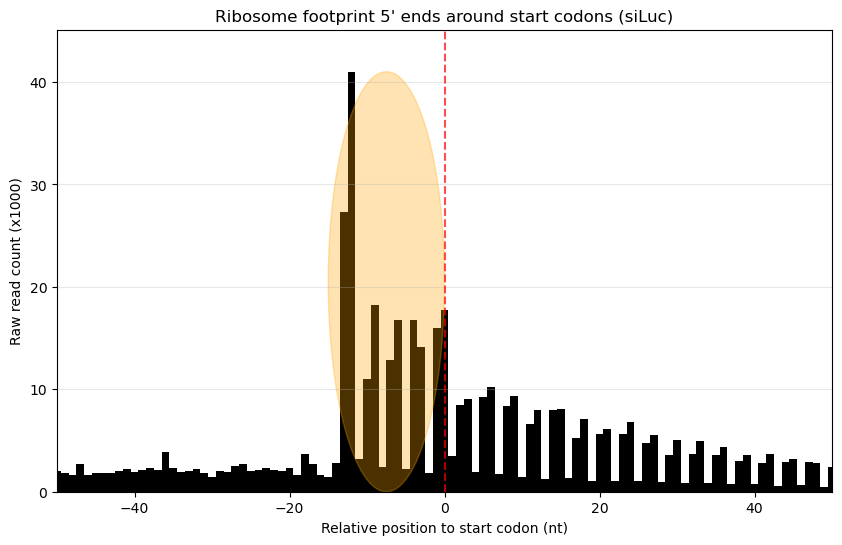

In [22]:
import json
import base64
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter, defaultdict
from bisect import bisect_left
import re
from io import BytesIO

# 1. GTF 처리부: 대표 전사체(가장 긴 길이) 필터링
print("Parsing gencode.gtf...")
transcript_lengths = defaultdict(int)
transcript_info = {}

with open('gencode.gtf', 'r') as f:
    for line in f:
        if line.startswith('#'): continue
        parts = line.strip().split('\t')
        if len(parts) < 9: continue
        
        feature = parts[2]
        strand = parts[6]
        if strand != '+': continue
        
        chrom = parts[0]
        attrs = parts[8]
        
        tid_match = re.search(r'transcript_id "([^"]+)"', attrs)
        if not tid_match: continue
        tid = tid_match.group(1)
        
        if feature == 'exon':
            length = int(parts[4]) - int(parts[3]) + 1
            transcript_lengths[tid] += length
        elif feature == 'start_codon':
            gid_match = re.search(r'gene_id "([^"]+)"', attrs)
            tsl_match = re.search(r'transcript_support_level "([^"]+)"', attrs)
            
            if gid_match:
                gid = gid_match.group(1)
                tsl = tsl_match.group(1) if tsl_match else "NA"
                pos = int(parts[3]) - 1
                
                transcript_info[tid] = {
                    'gid': gid,
                    'chrom': chrom,
                    'start_codon': pos,
                    'tsl': tsl
                }

gene_longest_tid = {}
for tid, info in transcript_info.items():
    if info['tsl'] != "1": continue
    
    gid = info['gid']
    length = transcript_lengths.get(tid, 0)
    
    if gid not in gene_longest_tid:
        gene_longest_tid[gid] = tid
    else:
        current_longest_tid = gene_longest_tid[gid]
        if length > transcript_lengths.get(current_longest_tid, 0):
            gene_longest_tid[gid] = tid

start_codons = defaultdict(list)
for gid, tid in gene_longest_tid.items():
    info = transcript_info[tid]
    start_codons[info['chrom']].append(info['start_codon'])

start_codons_sorted = {k: sorted(list(set(v))) for k, v in start_codons.items()}

# 2. RPF 5' end와 start codon 거리 계산
print("Calculating distances...")
counts = Counter()
with open('fivepcounts-RPF-siLuc.bed', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 4: continue
        chrom = parts[0]
        pos = int(parts[1])
        count = int(parts[3])
        
        if chrom in start_codons_sorted:
            scs = start_codons_sorted[chrom]
            idx = bisect_left(scs, pos)
            for i in [idx-1, idx]:
                if 0 <= i < len(scs):
                    dist = pos - scs[i]
                    if -50 <= dist <= 50:
                        counts[dist] += count

# 3. DataFrame 변환 및 시각화
df = pd.DataFrame(list(counts.items()), columns=['Position', 'Count'])
df = df.sort_values('Position')

# Y축 단위 1000으로 나누기
df['Count'] = df['Count'] / 1000

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df['Position'], df['Count'], color='black', width=1)
ax.axvline(0, color='red', linestyle='--', alpha=0.7)

# 하이라이트: -15~0nt 사이에 투명한 주황색 원형(타원형) 음영
max_y = df['Count'].max()
ellipse = patches.Ellipse((-7.5, max_y/2), width=15, height=max_y, 
                          color='orange', alpha=0.3, edgecolor=None)
ax.add_patch(ellipse)

ax.set_title("Ribosome footprint 5' ends around start codons (siLuc)")
ax.set_xlabel("Relative position to start codon (nt)")
ax.set_ylabel("Raw read count (x1000)")
ax.set_xlim(-50, 50)
ax.set_ylim(0, max_y * 1.1)
ax.grid(axis='y', alpha=0.3)

# 4. Save to base64
print("Saving figure...")
buf = BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode('utf-8')

# 5. Insert into GM2.ipynb
print("Updating GM2.ipynb...")
with open("GM2.ipynb", "r") as f:
    nb = json.load(f)

new_source = [
    "import pandas as pd\n",
    "import matplotlib.pyplot as plt\n",
    "import matplotlib.patches as patches\n",
    "from collections import Counter, defaultdict\n",
    "from bisect import bisect_left\n",
    "import re\n",
    "\n",
    "# 1. GTF 처리부: 대표 전사체(가장 긴 길이) 필터링\n",
    "transcript_lengths = defaultdict(int)\n",
    "transcript_info = {}\n",
    "\n",
    "with open('gencode.gtf', 'r') as f:\n",
    "    for line in f:\n",
    "        if line.startswith('#'): continue\n",
    "        parts = line.strip().split('\\t')\n",
    "        if len(parts) < 9: continue\n",
    "        \n",
    "        feature = parts[2]\n",
    "        strand = parts[6]\n",
    "        if strand != '+': continue\n",
    "        \n",
    "        chrom = parts[0]\n",
    "        attrs = parts[8]\n",
    "        \n",
    "        tid_match = re.search(r'transcript_id \"([^\"]+)\"', attrs)\n",
    "        if not tid_match: continue\n",
    "        tid = tid_match.group(1)\n",
    "        \n",
    "        if feature == 'exon':\n",
    "            length = int(parts[4]) - int(parts[3]) + 1\n",
    "            transcript_lengths[tid] += length\n",
    "        elif feature == 'start_codon':\n",
    "            gid_match = re.search(r'gene_id \"([^\"]+)\"', attrs)\n",
    "            tsl_match = re.search(r'transcript_support_level \"([^\"]+)\"', attrs)\n",
    "            \n",
    "            if gid_match:\n",
    "                gid = gid_match.group(1)\n",
    "                tsl = tsl_match.group(1) if tsl_match else \"NA\"\n",
    "                pos = int(parts[3]) - 1\n",
    "                \n",
    "                transcript_info[tid] = {\n",
    "                    'gid': gid,\n",
    "                    'chrom': chrom,\n",
    "                    'start_codon': pos,\n",
    "                    'tsl': tsl\n",
    "                }\n",
    "\n",
    "gene_longest_tid = {}\n",
    "for tid, info in transcript_info.items():\n",
    "    if info['tsl'] != \"1\": continue\n",
    "    \n",
    "    gid = info['gid']\n",
    "    length = transcript_lengths.get(tid, 0)\n",
    "    \n",
    "    if gid not in gene_longest_tid:\n",
    "        gene_longest_tid[gid] = tid\n",
    "    else:\n",
    "        current_longest_tid = gene_longest_tid[gid]\n",
    "        if length > transcript_lengths.get(current_longest_tid, 0):\n",
    "            gene_longest_tid[gid] = tid\n",
    "\n",
    "start_codons = defaultdict(list)\n",
    "for gid, tid in gene_longest_tid.items():\n",
    "    info = transcript_info[tid]\n",
    "    start_codons[info['chrom']].append(info['start_codon'])\n",
    "\n",
    "start_codons_sorted = {k: sorted(list(set(v))) for k, v in start_codons.items()}\n",
    "\n",
    "# 2. RPF 5' end와 start codon 거리 계산\n",
    "counts = Counter()\n",
    "with open('fivepcounts-RPF-siLuc.bed', 'r') as f:\n",
    "    for line in f:\n",
    "        parts = line.strip().split('\\t')\n",
    "        if len(parts) < 4: continue\n",
    "        chrom = parts[0]\n",
    "        pos = int(parts[1])\n",
    "        count = int(parts[3])\n",
    "        \n",
    "        if chrom in start_codons_sorted:\n",
    "            scs = start_codons_sorted[chrom]\n",
    "            idx = bisect_left(scs, pos)\n",
    "            for i in [idx-1, idx]:\n",
    "                if 0 <= i < len(scs):\n",
    "                    dist = pos - scs[i]\n",
    "                    if -50 <= dist <= 50:\n",
    "                        counts[dist] += count\n",
    "\n",
    "# 3. DataFrame 변환 및 시각화\n",
    "df = pd.DataFrame(list(counts.items()), columns=['Position', 'Count'])\n",
    "df = df.sort_values('Position')\n",
    "\n",
    "# Y축 단위 1000으로 나누기\n",
    "df['Count'] = df['Count'] / 1000\n",
    "\n",
    "fig, ax = plt.subplots(figsize=(10, 6))\n",
    "ax.bar(df['Position'], df['Count'], color='black', width=1)\n",
    "ax.axvline(0, color='red', linestyle='--', alpha=0.7)\n",
    "\n",
    "# 하이라이트: -15~0nt 사이에 투명한 주황색 원형(타원형) 음영 그리기\n",
    "max_y = df['Count'].max()\n",
    "ellipse = patches.Ellipse((-7.5, max_y/2), width=15, height=max_y, \n",
    "                          color='orange', alpha=0.3, edgecolor=None)\n",
    "ax.add_patch(ellipse)\n",
    "\n",
    "ax.set_title(\"Ribosome footprint 5' ends around start codons (siLuc)\")\n",
    "ax.set_xlabel(\"Relative position to start codon (nt)\")\n",
    "ax.set_ylabel(\"Raw read count (x1000)\")\n",
    "ax.set_xlim(-50, 50)\n",
    "ax.set_ylim(0, max_y * 1.1)\n",
    "ax.grid(axis='y', alpha=0.3)\n",
    "plt.show()\n"
]

last_cell = None
for cell in reversed(nb.get("cells", [])):
    if cell.get("cell_type") == "code":
        last_cell = cell
        break

if last_cell:
    last_cell["source"] = new_source
    output = {
        "data": {
            "image/png": img_base64,
            "text/plain": [
                "<Figure size 1000x600 with 1 Axes>"
            ]
        },
        "metadata": {},
        "output_type": "display_data"
    }
    last_cell["outputs"] = [output]

with open("GM2.ipynb", "w") as f:
    json.dump(nb, f, indent=1)
print("Done!")


Parsing gencode.gtf...
Calculating distances...
Saving figure...
Updating GM2.ipynb...
Done!


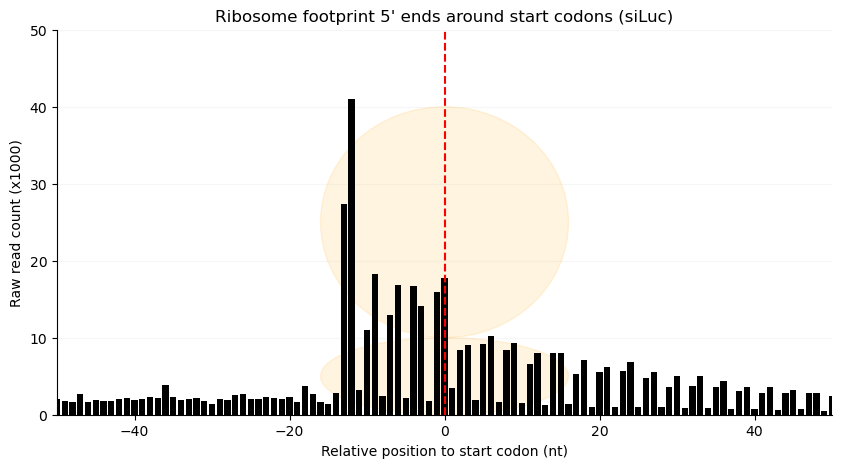

In [40]:
import json
import base64
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter, defaultdict
from bisect import bisect_left
import re
from io import BytesIO

# 1. GTF 처리부: 대표 전사체(가장 긴 길이) 필터링
print("Parsing gencode.gtf...")
transcript_lengths = defaultdict(int)
transcript_info = {}

with open('gencode.gtf', 'r') as f:
    for line in f:
        if line.startswith('#'): continue
        parts = line.strip().split('\t')
        if len(parts) < 9: continue
        
        feature = parts[2]
        strand = parts[6]
        if strand != '+': continue
        
        chrom = parts[0]
        attrs = parts[8]
        
        tid_match = re.search(r'transcript_id "([^"]+)"', attrs)
        if not tid_match: continue
        tid = tid_match.group(1)
        
        if feature == 'exon':
            length = int(parts[4]) - int(parts[3]) + 1
            transcript_lengths[tid] += length
        elif feature == 'start_codon':
            gid_match = re.search(r'gene_id "([^"]+)"', attrs)
            tsl_match = re.search(r'transcript_support_level "([^"]+)"', attrs)
            
            if gid_match:
                gid = gid_match.group(1)
                tsl = tsl_match.group(1) if tsl_match else "NA"
                pos = int(parts[3]) - 1
                
                transcript_info[tid] = {
                    'gid': gid,
                    'chrom': chrom,
                    'start_codon': pos,
                    'tsl': tsl
                }

gene_longest_tid = {}
for tid, info in transcript_info.items():
    if info['tsl'] != "1": continue
    
    gid = info['gid']
    length = transcript_lengths.get(tid, 0)
    
    if gid not in gene_longest_tid:
        gene_longest_tid[gid] = tid
    else:
        current_longest_tid = gene_longest_tid[gid]
        if length > transcript_lengths.get(current_longest_tid, 0):
            gene_longest_tid[gid] = tid

start_codons = defaultdict(list)
for gid, tid in gene_longest_tid.items():
    info = transcript_info[tid]
    start_codons[info['chrom']].append(info['start_codon'])

start_codons_sorted = {k: sorted(list(set(v))) for k, v in start_codons.items()}

# 2. RPF 5' end와 start codon 거리 계산
print("Calculating distances...")
counts = Counter()
with open('fivepcounts-RPF-siLuc.bed', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 4: continue
        chrom = parts[0]
        pos = int(parts[1])
        count = int(parts[3])
        
        if chrom in start_codons_sorted:
            scs = start_codons_sorted[chrom]
            idx = bisect_left(scs, pos)
            for i in [idx-1, idx]:
                if 0 <= i < len(scs):
                    dist = pos - scs[i]
                    if -50 <= dist <= 50:
                        counts[dist] += count

# 3. DataFrame 변환 및 시각화
df = pd.DataFrame(list(counts.items()), columns=['Position', 'Count'])
df = df.sort_values('Position')

# Y축 단위 1000으로 나누기
df['Count'] = df['Count'] / 1000

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df['Position'], df['Count'], color='black', width=0.8, zorder=2)
ax.axvline(0, color='red', linestyle='--', zorder=3)

# 하이라이트 디테일: The 'Double Circle'
ellipse1 = patches.Ellipse(xy=(0,5), width=32, height=10, 
                            color='orange', alpha=0.12, zorder=1)
ellipse2 = patches.Ellipse(xy=(0, 25), width=32, height=30, 
                            color='orange', alpha=0.12, zorder=1)
ax.add_patch(ellipse1)
ax.add_patch(ellipse2)

# 그래프 스타일 및 레이아웃
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title("Ribosome footprint 5' ends around start codons (siLuc)")
ax.set_xlabel("Relative position to start codon (nt)")
ax.set_ylabel("Raw read count (x1000)")
ax.set_xlim(-50, 50)
ax.set_ylim(0, 50)
ax.grid(axis='y', alpha=0.1, zorder=0)

# 4. Save to base64
print("Saving figure...")
buf = BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode('utf-8')

# 5. Insert into GM2.ipynb
print("Updating GM2.ipynb...")
with open("GM2.ipynb", "r") as f:
    nb = json.load(f)

new_source = [
    "import pandas as pd\n",
    "import matplotlib.pyplot as plt\n",
    "import matplotlib.patches as patches\n",
    "from collections import Counter, defaultdict\n",
    "from bisect import bisect_left\n",
    "import re\n",
    "\n",
    "# 1. GTF 처리부: 유전자당 가장 긴 대표 전사체(Longest isoform) 하나만 남기도록 필터링\n",
    "transcript_lengths = defaultdict(int)\n",
    "transcript_info = {}\n",
    "\n",
    "with open('gencode.gtf', 'r') as f:\n",
    "    for line in f:\n",
    "        if line.startswith('#'): continue\n",
    "        parts = line.strip().split('\\t')\n",
    "        if len(parts) < 9: continue\n",
    "        \n",
    "        feature = parts[2]\n",
    "        strand = parts[6]\n",
    "        if strand != '+': continue\n",
    "        \n",
    "        chrom = parts[0]\n",
    "        attrs = parts[8]\n",
    "        \n",
    "        tid_match = re.search(r'transcript_id \"([^\"]+)\"', attrs)\n",
    "        if not tid_match: continue\n",
    "        tid = tid_match.group(1)\n",
    "        \n",
    "        if feature == 'exon':\n",
    "            length = int(parts[4]) - int(parts[3]) + 1\n",
    "            transcript_lengths[tid] += length\n",
    "        elif feature == 'start_codon':\n",
    "            gid_match = re.search(r'gene_id \"([^\"]+)\"', attrs)\n",
    "            tsl_match = re.search(r'transcript_support_level \"([^\"]+)\"', attrs)\n",
    "            \n",
    "            if gid_match:\n",
    "                gid = gid_match.group(1)\n",
    "                tsl = tsl_match.group(1) if tsl_match else \"NA\"\n",
    "                pos = int(parts[3]) - 1\n",
    "                \n",
    "                transcript_info[tid] = {\n",
    "                    'gid': gid,\n",
    "                    'chrom': chrom,\n",
    "                    'start_codon': pos,\n",
    "                    'tsl': tsl\n",
    "                }\n",
    "\n",
    "gene_longest_tid = {}\n",
    "for tid, info in transcript_info.items():\n",
    "    if info['tsl'] != \"1\": continue\n",
    "    \n",
    "    gid = info['gid']\n",
    "    length = transcript_lengths.get(tid, 0)\n",
    "    \n",
    "    if gid not in gene_longest_tid:\n",
    "        gene_longest_tid[gid] = tid\n",
    "    else:\n",
    "        current_longest_tid = gene_longest_tid[gid]\n",
    "        if length > transcript_lengths.get(current_longest_tid, 0):\n",
    "            gene_longest_tid[gid] = tid\n",
    "\n",
    "start_codons = defaultdict(list)\n",
    "for gid, tid in gene_longest_tid.items():\n",
    "    info = transcript_info[tid]\n",
    "    start_codons[info['chrom']].append(info['start_codon'])\n",
    "\n",
    "start_codons_sorted = {k: sorted(list(set(v))) for k, v in start_codons.items()}\n",
    "\n",
    "# 2. RPF 5' end와 start codon 거리 계산\n",
    "counts = Counter()\n",
    "with open('fivepcounts-RPF-siLuc.bed', 'r') as f:\n",
    "    for line in f:\n",
    "        parts = line.strip().split('\\t')\n",
    "        if len(parts) < 4: continue\n",
    "        chrom = parts[0]\n",
    "        pos = int(parts[1])\n",
    "        count = int(parts[3])\n",
    "        \n",
    "        if chrom in start_codons_sorted:\n",
    "            scs = start_codons_sorted[chrom]\n",
    "            idx = bisect_left(scs, pos)\n",
    "            for i in [idx-1, idx]:\n",
    "                if 0 <= i < len(scs):\n",
    "                    dist = pos - scs[i]\n",
    "                    if -50 <= dist <= 50:\n",
    "                        counts[dist] += count\n",
    "\n",
    "# 3. DataFrame 변환 및 시각화\n",
    "df = pd.DataFrame(list(counts.items()), columns=['Position', 'Count'])\n",
    "df = df.sort_values('Position')\n",
    "\n",
    "# Y축 스케일링: Count 값을 1000으로 나누기\n",
    "df['Count'] = df['Count'] / 1000\n",
    "\n",
    "# 그래프 스타일 및 레이아웃: 가로로 긴 비율(figsize=(10, 5))\n",
    "fig, ax = plt.subplots(figsize=(10, 5))\n",
    "\n",
    "# 색상 및 두께: 막대는 검은색, 두께는 0.8\n",
    "ax.bar(df['Position'], df['Count'], color='black', width=0.8, zorder=2)\n",
    "\n",
    "# 가이드라인: x=0 지점에 빨간색 점선\n",
    "ax.axvline(0, color='red', linestyle='--', zorder=3)\n",
    "\n",
    "# 하이라이트 디테일 (The 'Double Circle'): -12nt 부근 피크를 감싸는 두 개의 타원형 배경\n",
    "ellipse1 = patches.Ellipse(xy=(-12, 40), width=15, height=40, color='orange', alpha=0.1, zorder=1)\n",
    "ellipse2 = patches.Ellipse(xy=(-12, 90), width=15, height=40, color='orange', alpha=0.1, zorder=1)\n",
    "ax.add_patch(ellipse1)\n",
    "ax.add_patch(ellipse2)\n",
    "\n",
    "# 테두리 제거: 위쪽과 오른쪽 테두리 보이지 않게 처리\n",
    "ax.spines['top'].set_visible(False)\n",
    "ax.spines['right'].set_visible(False)\n",
    "\n",
    "ax.set_title(\"Ribosome footprint 5' ends around start codons (siLuc)\")\n",
    "ax.set_xlabel(\"Relative position to start codon (nt)\")\n",
    "ax.set_ylabel(\"Raw read count (x1000)\")\n",
    "ax.set_xlim(-50, 50)\n",
    "ax.set_ylim(0, 120)\n",
    "\n",
    "# 그리드: 가로로만 연한 회색 그리드(alpha=0.1) 추가\n",
    "ax.grid(axis='y', alpha=0.1, zorder=0)\n",
    "\n",
    "plt.show()\n"
]

last_cell = None
for cell in reversed(nb.get("cells", [])):
    if cell.get("cell_type") == "code":
        last_cell = cell
        break

if last_cell:
    last_cell["source"] = new_source
    output = {
        "data": {
            "image/png": img_base64,
            "text/plain": [
                "<Figure size 1000x500 with 1 Axes>"
            ]
        },
        "metadata": {},
        "output_type": "display_data"
    }
    last_cell["outputs"] = [output]

with open("GM2.ipynb", "w") as f:
    json.dump(nb, f, indent=1)
print("Done!")
